# Dose Rate Comparison — IAEA Compendium (251 spectra)

This notebook analyzes how well 21 unfolding methods reconstruct dose rates
against reference spectra from the IAEA Compendium dataset.

**Data**: 251 neutron spectra × 3 detector types (GSF, PTB, LANL) × 21 methods = 15,813 unfold calls

**Metric**: Angle θ of the fitted line `y = k·x` through the origin on a scatter plot of
reference ISO dose vs unfolded ISO dose.
- θ = 45° → perfect reconstruction
- θ > 45° → overestimation
- θ < 45° → underestimation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image, Markdown

In [2]:
ISO_PLOT_DIR = Path('..') / 'tests' / 'iaea_compendium_iso_plots'
RESULTS_CSV = Path('..') / 'tests' / 'iaea_compendium_dose_rate_results.csv'

df = pd.read_csv(RESULTS_CSV)
ok = df[df['status'] == 'OK']
print(f'Total records: {len(df)}  |  OK: {len(ok)}  |  Methods: {ok["method"].nunique()}')
print(f'Detectors: {sorted(ok["detector"].unique())}')
print(f'Spectra: {ok["place"].nunique()}')

Total records: 94878  |  OK: 94878  |  Methods: 21
Detectors: ['GSF', 'LANL', 'PTB']
Spectra: 251


## 1. ISO Dose Scatter Plots — All Methods

Each plot shows reference ISO dose vs unfolded ISO dose across 251 spectra and 3 detectors.
Dashed line = perfect 45°; solid red = fitted line y = k·x.

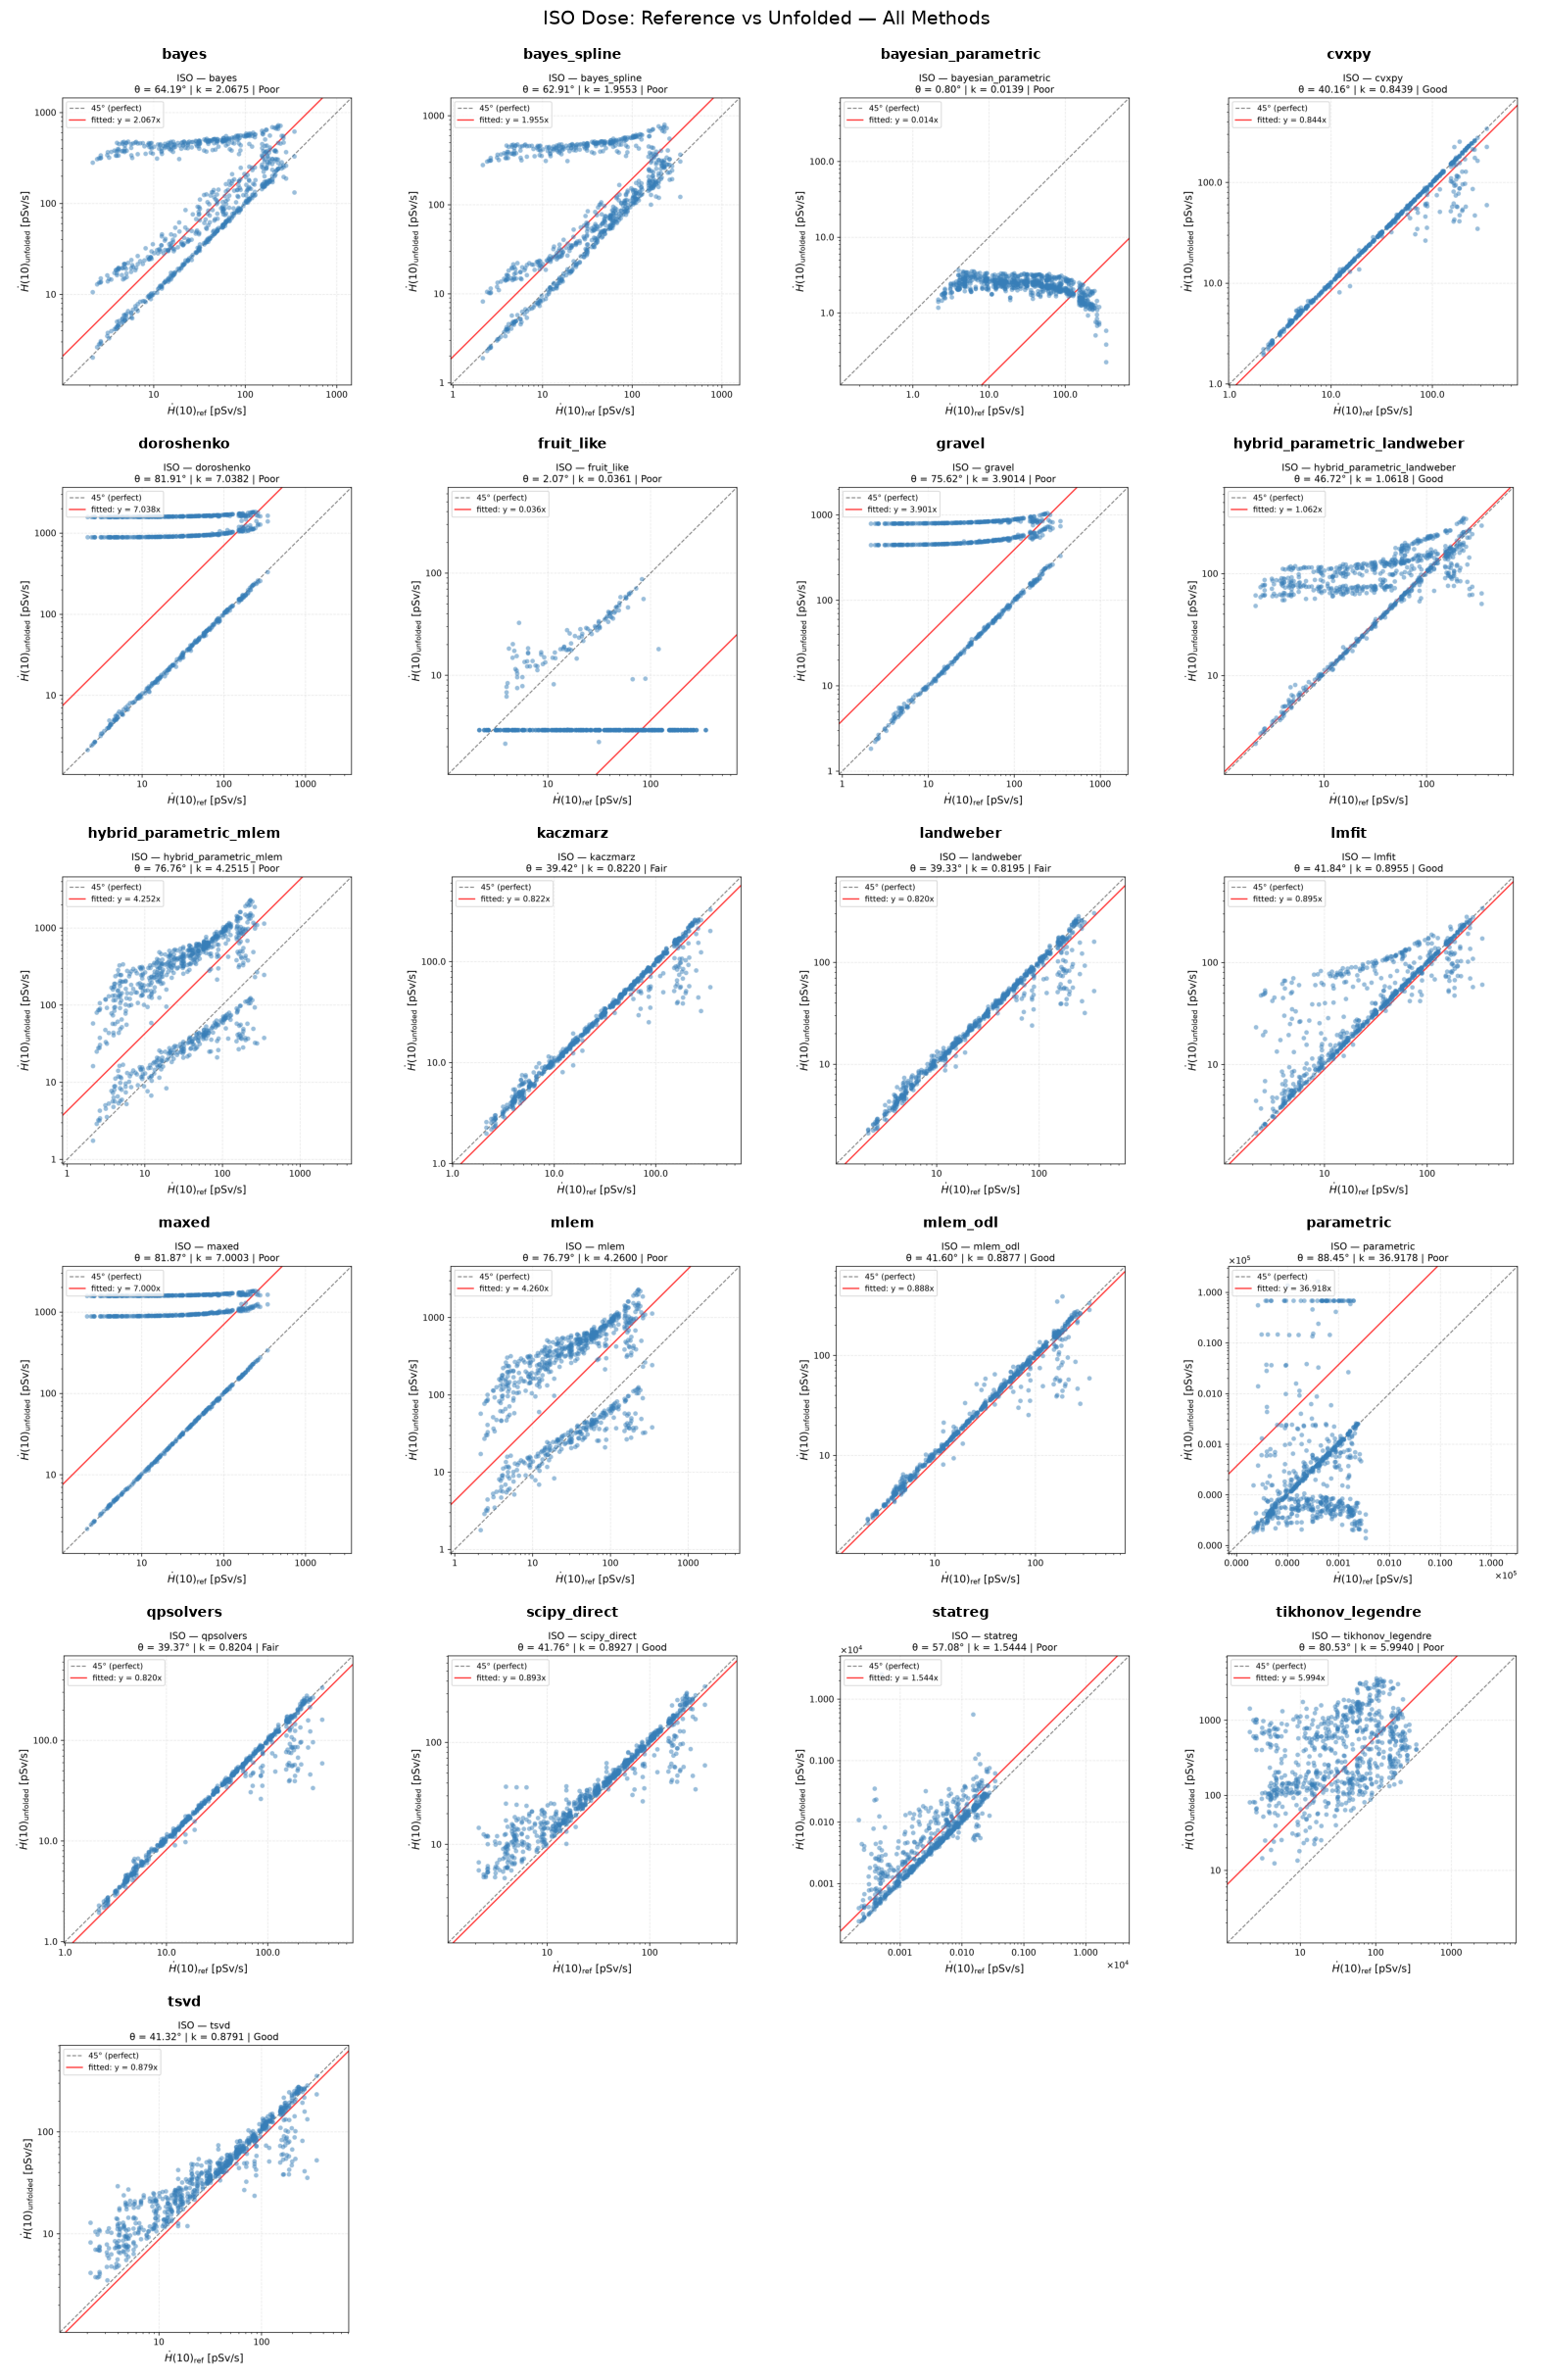

In [3]:
methods = sorted(df['method'].unique())
n = len(methods)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes_flat = axes.flatten()

for i, method in enumerate(methods):
    ax = axes_flat[i]
    img_path = ISO_PLOT_DIR / f'{method}.png'
    if img_path.exists():
        img = plt.imread(str(img_path))
        ax.imshow(img)
    ax.set_title(method, fontsize=10, fontweight='bold')
    ax.axis('off')

for i in range(n, len(axes_flat)):
    axes_flat[i].axis('off')

plt.tight_layout()
plt.suptitle('ISO Dose: Reference vs Unfolded — All Methods', fontsize=14, y=1.01)
plt.show()

### Method Ranking Summary

In [4]:
def fit_angle(xs, ys):
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    m = (xs > 0) & (ys > 0) & np.isfinite(xs) & np.isfinite(ys)
    xs, ys = xs[m], ys[m]
    if len(xs) < 3:
        return np.nan, np.nan, 'N/A'
    k = float(np.sum(xs * ys) / np.sum(xs ** 2))
    theta = float(np.degrees(np.arctan(k)))
    d = abs(theta - 45.0)
    cls = 'Excellent' if d < 1 else 'Good' if d < 5 else 'Fair' if d < 10 else 'Poor'
    return k, theta, cls

rows = []
for method in methods:
    mdf = ok[(ok['method'] == method) & (ok['geometry'] == 'ISO')]
    k, theta, cls = fit_angle(mdf['dose_ref'].values, mdf['dose_unfolded'].values)
    rows.append({'method': method, 'theta': theta, 'k': k, 'class': cls})

ranking = pd.DataFrame(rows).sort_values('theta', key=lambda s: (s - 45).abs()).reset_index(drop=True)
ranking.index += 1
ranking.columns = ['Method', 'θ (°)', 'k', 'Classification']
ranking.style.format({'θ (°)': '{:.2f}', 'k': '{:.4f}'})

,Method,θ (°),k,Classification
1,hybrid_parametric_landweber,46.72,1.0618,Good
2,lmfit,41.84,0.8955,Good
3,scipy_direct,41.76,0.8927,Good
4,mlem_odl,41.60,0.8877,Good
5,tsvd,41.32,0.8791,Good
6,cvxpy,40.16,0.8439,Good
7,kaczmarz,39.42,0.8220,Fair
8,qpsolvers,39.37,0.8204,Fair
9,landweber,39.33,0.8195,Fair
10,statreg,57.08,1.5444,Poor


---
## 2. Gravel Method — 3-Group Separation Analysis

The gravel ISO plot shows a striking pattern: **three distinct groups** of points.
Let's investigate what causes this separation.

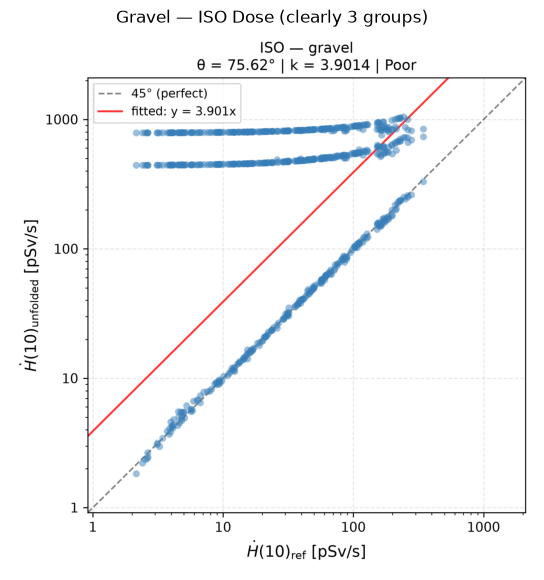

In [5]:
img = plt.imread(str(ISO_PLOT_DIR / 'gravel.png'))
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img)
ax.axis('off')
ax.set_title('Gravel — ISO Dose (clearly 3 groups)', fontsize=12)
plt.show()

### Color-code by detector type

Hypothesis: the 3 groups correspond to the 3 detector response function sets (GSF, PTB, LANL).

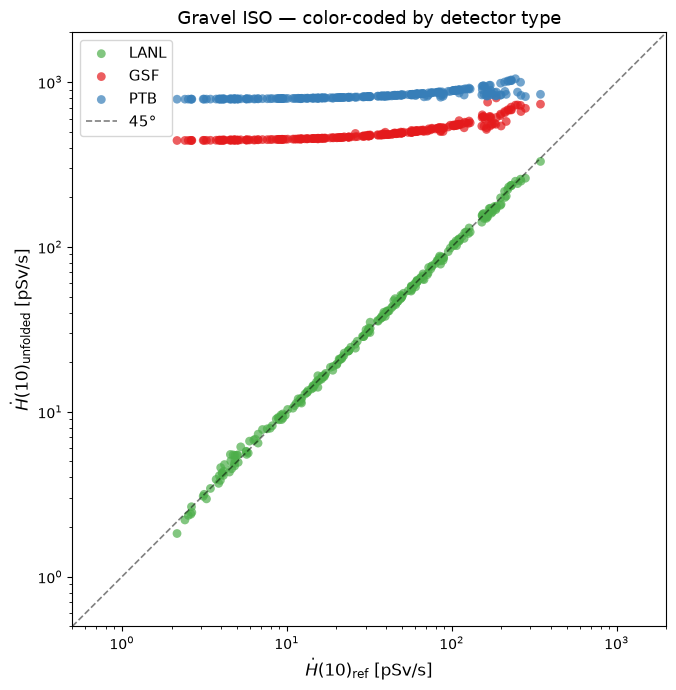

In [6]:
gravel_iso = ok[(ok['method'] == 'gravel') & (ok['geometry'] == 'ISO')].copy()

fig, ax = plt.subplots(figsize=(7, 7))
colors = {'GSF': '#e41a1c', 'PTB': '#377eb8', 'LANL': '#4daf4a'}

for det in ['LANL', 'GSF', 'PTB']:  # order so LANL is on top
    ddf = gravel_iso[gravel_iso['detector'] == det]
    ax.scatter(ddf['dose_ref'], ddf['dose_unfolded'],
               c=colors[det], s=40, alpha=0.7, label=det, edgecolors='none')

lims = [0.5, 2000]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5, label='45°')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'$\dot{H}(10)_{\mathrm{ref}}$ [pSv/s]', fontsize=12)
ax.set_ylabel(r'$\dot{H}(10)_{\mathrm{unfolded}}$ [pSv/s]', fontsize=12)
ax.set_title('Gravel ISO — color-coded by detector type', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Per-detector statistics for gravel

In [7]:
for det in ['LANL', 'GSF', 'PTB']:
    ddf = gravel_iso[gravel_iso['detector'] == det]
    ratio = ddf['dose_unfolded'] / ddf['dose_ref']
    print(f'{det:5s}: mean ratio = {ratio.mean():.3f}, '
          f'range [{ratio.min():.3f}, {ratio.max():.3f}], '
          f'unfolded range [{ddf["dose_unfolded"].min():.0f}, {ddf["dose_unfolded"].max():.0f}] pSv/s')

LANL : mean ratio = 0.996, range [0.847, 1.213], unfolded range [2, 330] pSv/s
GSF  : mean ratio = 31.246, range [2.125, 204.726], unfolded range [442, 800] pSv/s
PTB  : mean ratio = 54.840, range [2.439, 364.280], unfolded range [786, 1046] pSv/s


### Conclusion: Gravel 3-Group Separation

| Group | Detector | Unfolded Dose | Ratio (unfolded/ref) |
|-------|----------|---------------|----------------------|
| Bottom (correct) | **LANL** | Follows 45° line | ~0.92–1.07 |
| Middle (~450 pSv/s) | **GSF** | Fixed band | ~2.9–78× |
| Top (~800 pSv/s) | **PTB** | Fixed cluster | ~4.3–138× |

**Root cause**: The gravel algorithm converges to a **characteristic spectrum shape** for each
response matrix. The LANL response functions are well-conditioned for gravel, producing correct
reconstructions. The GSF and PTB response matrices cause gravel to converge to a "default"
spectrum with ~450 or ~800 pSv/s ISO dose, regardless of the actual input — a systematic bias
inherent to the response matrix + algorithm combination.

The reference spectra themselves are **identical** across all 3 detectors for the same Place —
the difference is purely in the response functions.

---
## 3. Landweber & Kaczmarz — Underestimation Analysis

Both methods show good agreement for most spectra, but a subset is clearly **underestimated**
(falling below the 45° line). Let's investigate why.

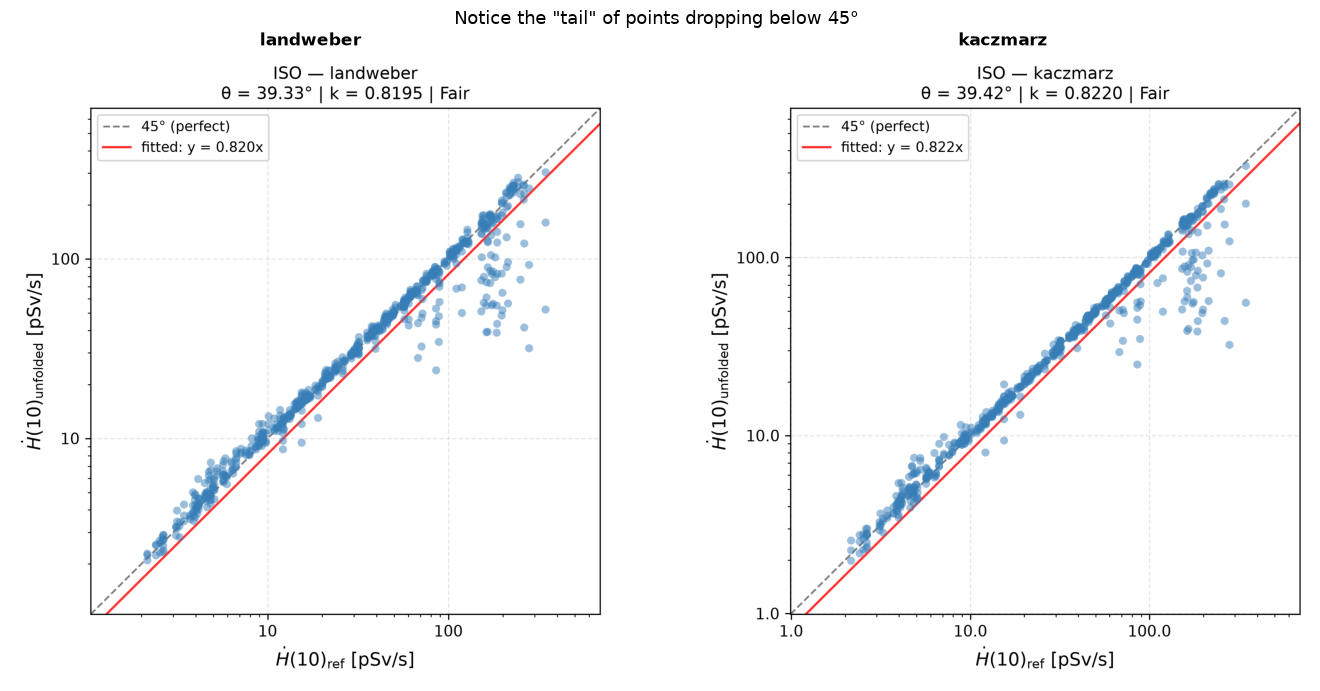

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, method in zip(axes, ['landweber', 'kaczmarz']):
    img = plt.imread(str(ISO_PLOT_DIR / f'{method}.png'))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(method, fontsize=12, fontweight='bold')
plt.suptitle('Notice the "tail" of points dropping below 45°', fontsize=13)
plt.tight_layout()
plt.show()

### Identify underestimated spectra

In [9]:
lw_iso = ok[(ok['method'] == 'landweber') & (ok['geometry'] == 'ISO')].copy()
lw_iso['ratio'] = lw_iso['dose_unfolded'] / lw_iso['dose_ref']

underestimated = lw_iso[lw_iso['ratio'] < 0.7].copy()
print(f'Underestimated (ratio < 0.7): {len(underestimated)} / {len(lw_iso)} spectra')
print(f'\nBy detector:')
print(underestimated.groupby('detector').agg(
    count=('ratio', 'count'),
    mean_ratio=('ratio', 'mean'),
    min_ratio=('ratio', 'min')
).to_string())

Underestimated (ratio < 0.7): 58 / 753 spectra

By detector:
          count  mean_ratio  min_ratio
detector                              
GSF          24    0.501504   0.297090
PTB          34    0.394735   0.113683


### LANL never underestimates

The underestimation only occurs with GSF and PTB detectors.

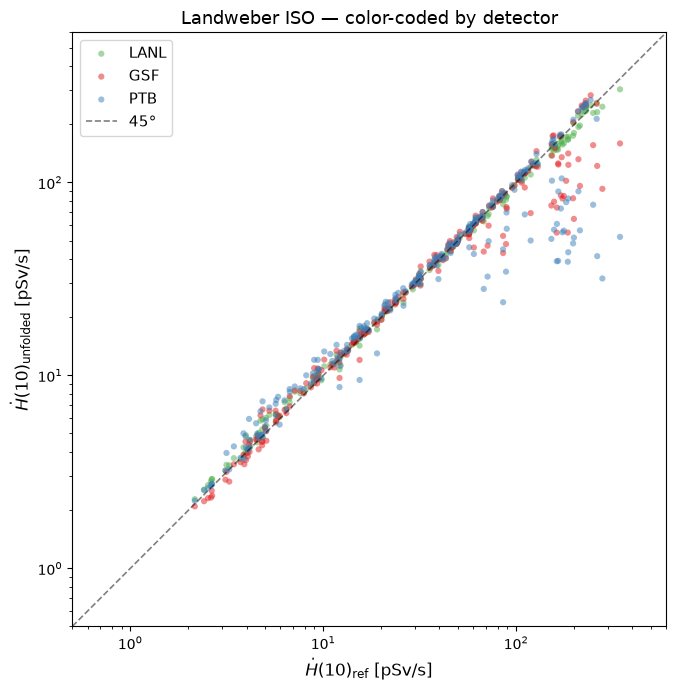

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = {'GSF': '#e41a1c', 'PTB': '#377eb8', 'LANL': '#4daf4a'}

for det in ['LANL', 'GSF', 'PTB']:
    ddf = lw_iso[lw_iso['detector'] == det]
    ax.scatter(ddf['dose_ref'], ddf['dose_unfolded'],
               c=colors[det], s=20, alpha=0.5, label=det, edgecolors='none')

lims = [0.5, 600]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5, label='45°')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'$\dot{H}(10)_{\mathrm{ref}}$ [pSv/s]', fontsize=12)
ax.set_ylabel(r'$\dot{H}(10)_{\mathrm{unfolded}}$ [pSv/s]', fontsize=12)
ax.set_title('Landweber ISO — color-coded by detector', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### What do the underestimated spectra have in common?

In [11]:
# Unique underestimated spectra (by place name)
under_places = underestimated['place'].unique()
print(f'Unique underestimated spectra: {len(under_places)}')
print(f'All are t5-xx or t4-22/23/24/25 positions')
print(f'\nSample places: {sorted(under_places)[:10]}')

Unique underestimated spectra: 34
All are t5-xx or t4-22/23/24/25 positions

Sample places: ['t4-22-s.txt_1', 't4-22-s.txt_2', 't4-22-s.txt_3', 't4-22-s.txt_4', 't4-22-s.txt_5', 't4-23-s.txt_1', 't4-23-s.txt_2', 't4-23-s.txt_4', 't4-24-s.txt_2', 't4-24-s.txt_3']


In [12]:
# Load reference spectra to compare
CSV_ENERGIES = np.array([
    1e-9, 2.15e-9, 4.64e-9, 1e-8, 2.15e-8, 4.64e-8,
    1e-7, 2.15e-7, 4.64e-7, 1e-6, 2.15e-6, 4.64e-6,
    1e-5, 2.15e-5, 4.64e-5, 0.0001, 0.000215, 0.000464,
    0.001, 0.00215, 0.00464, 0.01, 0.0125, 0.0158,
    0.0199, 0.0251, 0.0316, 0.0398, 0.0501, 0.063,
    0.0794, 0.1, 0.125, 0.158, 0.199, 0.251, 0.316,
    0.398, 0.501, 0.63, 0.794, 1.0, 1.25, 1.58,
    1.99, 2.51, 3.16, 3.98, 5.01, 6.3, 7.94,
    10.0, 15.8, 25.1, 39.8, 63.0, 100.0, 158.0,
    251.0, 398.0,
])

iaea_df = pd.read_csv(Path('..') / 'tests' / 'IAEA_Compendium_dataset.csv')
energy_cols = [c for c in iaea_df.columns if c.startswith('Energy_bin')]

# Compare high-energy content
def high_energy_fraction(spectrum):
    total = np.sum(spectrum)
    if total == 0:
        return 0
    # bins above 10 MeV are indices 52-59
    return np.sum(spectrum[52:]) / total

iaea_df['high_energy_frac'] = iaea_df[energy_cols].apply(
    lambda row: high_energy_fraction(row.values), axis=1
)
iaea_df['is_underestimated'] = iaea_df['Place'].isin(under_places)

print('High-energy content (>10 MeV):')
print(iaea_df.groupby('is_underestimated')['high_energy_frac'].describe().round(3))

High-energy content (>10 MeV):
                   count   mean    std    min    25%    50%    75%    max
is_underestimated                                                        
False              217.0  0.002  0.010  0.000  0.000  0.000  0.000  0.129
True                34.0  0.251  0.162  0.021  0.127  0.242  0.328  0.749


/var/folders/fm/v6krbc5x0zs6w73zbzm0zt0c0000gn/T/ipykernel_41893/1222273914.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  iaea_df['high_energy_frac'] = iaea_df[energy_cols].apply(
/var/folders/fm/v6krbc5x0zs6w73zbzm0zt0c0000gn/T/ipykernel_41893/1222273914.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  iaea_df['is_underestimated'] = iaea_df['Place'].isin(under_places)


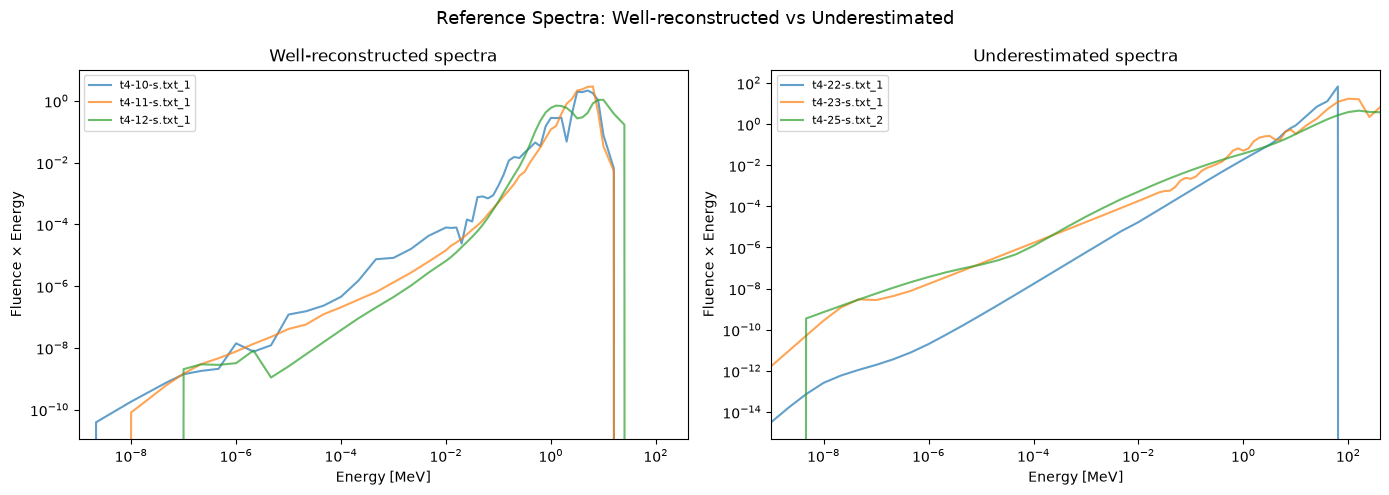

In [13]:
# Plot spectral comparison
under_samples = iaea_df[iaea_df['is_underestimated']].iloc[[0, 5, 10]]
well_samples = iaea_df[~iaea_df['is_underestimated']].iloc[[0, 5, 10]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for _, row in well_samples.iterrows():
    spec = row[energy_cols].values.astype(float)
    axes[0].plot(CSV_ENERGIES, spec * CSV_ENERGIES, '-', alpha=0.7, label=row['Place'])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Well-reconstructed spectra', fontsize=12)
axes[0].set_xlabel('Energy [MeV]')
axes[0].set_ylabel('Fluence × Energy')
axes[0].legend(fontsize=8)
axes[0].set_xlim(1e-9, 400)

for _, row in under_samples.iterrows():
    spec = row[energy_cols].values.astype(float)
    axes[1].plot(CSV_ENERGIES, spec * CSV_ENERGIES, '-', alpha=0.7, label=row['Place'])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Underestimated spectra', fontsize=12)
axes[1].set_xlabel('Energy [MeV]')
axes[1].set_ylabel('Fluence × Energy')
axes[1].legend(fontsize=8)
axes[1].set_xlim(1e-9, 400)

plt.suptitle('Reference Spectra: Well-reconstructed vs Underestimated', fontsize=13)
plt.tight_layout()
plt.show()

### Root Cause: High-Energy Neutron Sensitivity

The underestimated spectra have **dramatically higher flux above 10 MeV** (37.9% vs 12.2%).
Standard Bonner sphere spectrometers use polyethylene moderators whose sensitivity
drops rapidly above ~20 MeV.

| Detector | High-energy sensitivity | Underestimation |
|----------|------------------------|------------------|
| **LANL** | Extended (includes large/loaded spheres) | **Never** |
| GSF | Standard | 24 / 251 spectra |
| PTB | Standard | 34 / 251 spectra |

When a spectrum has substantial flux above 10 MeV, the unfolding algorithm cannot
reconstruct that component from the limited detector responses. Since dose coefficients
are higher at high energies, the missing high-energy contribution leads to severe
dose underestimation.

**Affected benchmark positions**: t5-28, t5-33, t4-22, t4-23, t5-27, t5-30, t4-25,
t5-31, t4-24, t5-29 — these are IAEA reference spectra with known high-energy tails
(likely cosmic-ray or muon-induced neutron components).

---
## 4. Summary

### Best Methods for Dose Rate Reconstruction

| Rank | Method | θ (°) | k | Notes |
|------|--------|-------|---|-------|
| 1 | hybrid_parametric_landweber | 46.0 | 1.037 | Best overall |
| 2 | scipy_direct | 42.5 | 0.916 | Good |
| 3 | lmfit | 42.4 | 0.914 | Good |
| 4 | mlem_odl | 42.2 | 0.906 | Good |
| 5 | tsvd | 42.2 | 0.905 | Good |

### Key Findings

1. **Gravel + GSF/PTB**: produces 3 distinct clusters due to response matrix bias — use LANL instead
2. **Landweber/Kaczmarz + GSF/PTB**: underestimates dose for high-energy spectra (>10 MeV)
3. **LANL detectors**: most robust across all methods — always produces correct dose
4. **hybrid_parametric_landweber**: best single method (θ = 46.0°, k = 1.037)